# 🎵 Práctica 1: Clasificador de Géneros Musicales con Deep Learning

### UTAMED - Universidad Tecnológica Atlántico Mediterráneo
### Deep Learning - Unidad 1: Fundamentos de Deep Learning | Sesión 2

---

> *"La música es el lenguaje universal de la humanidad... y ahora también de las redes neuronales."*

## 🎯 ¿Qué vamos a construir?

En esta práctica vamos a entrenar una **red neuronal feedforward (MLP)** con PyTorch para que aprenda a **clasificar canciones por género musical** a partir de sus características de audio, de forma similar a como lo hace el algoritmo de recomendación de **Spotify**.

Spotify analiza cada canción extrayendo atributos numéricos como:
- **Danceability** (¿se puede bailar?)
- **Energy** (¿cuánta intensidad tiene?)
- **Tempo** (¿a qué velocidad va?)
- **Valence** (¿transmite alegría o tristeza?)
- ... y muchos más.

Con estos datos, entrenaremos una red que distinga entre **Rock, Pop, Hip-Hop, Electrónica y Jazz**.

### 🧠 Conceptos de la Unidad 1 que aplicaremos:
| Concepto teórico | Aplicación en esta práctica |
|---|---|
| Tensores y matrices | Representación de features musicales |
| Redes feedforward (MLP) | Arquitectura del clasificador |
| Funciones de activación (ReLU) | Capas ocultas del modelo |
| Softmax + Cross Entropy | Clasificación multiclase |
| Backpropagation | Entrenamiento del modelo |
| Optimizadores (SGD, Adam...) | Batalla de optimizadores |
| Regularización (Dropout, L2) | Evitar sobreajuste |
| Batch Normalization | Estabilizar entrenamiento |


In [1]:
# ============================================================
# 📦 Instalación e importación de librerías
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Dispositivo (GPU si está disponible en Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Dispositivo: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Semillas para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(f"📦 PyTorch version: {torch.__version__}")
print("✅ Todo listo para empezar!")


🖥️ Dispositivo: cuda
   GPU: Tesla T4
📦 PyTorch version: 2.10.0+cu128
✅ Todo listo para empezar!


---
## 🎶 Parte 1: Los Datos — Features de Audio al Estilo Spotify

Spotify utiliza un sistema de análisis de audio que extrae **atributos numéricos** de cada canción. Estos son los que usaremos:

| Feature | Rango | Descripción |
|---|---|---|
| **Danceability** | 0 - 1 | ¿Es bailable? Basado en tempo, estabilidad rítmica, fuerza del beat |
| **Energy** | 0 - 1 | Intensidad y actividad. Death metal = alta, preludio de Bach = baja |
| **Loudness** | -60 - 0 dB | Volumen general de la pista |
| **Speechiness** | 0 - 1 | Presencia de palabras habladas (podcast ≈ 1, instrumental ≈ 0) |
| **Acousticness** | 0 - 1 | ¿Es acústica? Guitarra acústica = alta, sintetizador = baja |
| **Instrumentalness** | 0 - 1 | ¿Sin voz? Sinfonía = alta, canción pop = baja |
| **Liveness** | 0 - 1 | ¿Suena a grabación en vivo? |
| **Valence** | 0 - 1 | Positividad musical. Feliz/eufórico = alta, triste/enfadado = baja |
| **Tempo** | 60 - 200 BPM | Velocidad de la canción en beats por minuto |

> 🔗 **Conexión con la teoría:** Cada canción se representa como un **vector** de 9 dimensiones (un tensor 1D). Un lote de canciones forma una **matriz** (tensor 2D). Esto es exactamente la representación de datos que vimos en el apartado 3.1 de la unidad.


In [3]:
# ============================================================
# 🎲 Generación del dataset de música
# ============================================================
np.random.seed(42)
n_per_genre = 1000
genres = ['Rock', 'Pop', 'Hip-Hop', 'Electrónica', 'Jazz']
#GEneración de datos sinteticos basados en una normal
data = []
for genre in genres:
    n = n_per_genre
    if genre == 'Rock':
        d = {'danceability': np.random.normal(0.50, 0.12, n).clip(0, 1),
             'energy':       np.random.normal(0.75, 0.10, n).clip(0, 1),
             'loudness':     np.random.normal(-8, 3, n).clip(-60, 0),
             'speechiness':  np.random.normal(0.05, 0.03, n).clip(0, 1),
             'acousticness': np.random.normal(0.20, 0.15, n).clip(0, 1),
             'instrumentalness': np.random.normal(0.10, 0.10, n).clip(0, 1),
             'liveness':     np.random.normal(0.20, 0.10, n).clip(0, 1),
             'valence':      np.random.normal(0.50, 0.20, n).clip(0, 1),
             'tempo':        np.random.normal(125, 20, n).clip(60, 200)}
    elif genre == 'Pop':
        d = {'danceability': np.random.normal(0.70, 0.10, n).clip(0, 1),
             'energy':       np.random.normal(0.65, 0.12, n).clip(0, 1),
             'loudness':     np.random.normal(-6, 2.5, n).clip(-60, 0),
             'speechiness':  np.random.normal(0.08, 0.05, n).clip(0, 1),
             'acousticness': np.random.normal(0.25, 0.15, n).clip(0, 1),
             'instrumentalness': np.random.normal(0.02, 0.03, n).clip(0, 1),
             'liveness':     np.random.normal(0.15, 0.08, n).clip(0, 1),
             'valence':      np.random.normal(0.60, 0.18, n).clip(0, 1),
             'tempo':        np.random.normal(120, 15, n).clip(60, 200)}
    elif genre == 'Hip-Hop':
        d = {'danceability': np.random.normal(0.78, 0.08, n).clip(0, 1),
             'energy':       np.random.normal(0.65, 0.10, n).clip(0, 1),
             'loudness':     np.random.normal(-7, 2, n).clip(-60, 0),
             'speechiness':  np.random.normal(0.20, 0.10, n).clip(0, 1),
             'acousticness': np.random.normal(0.15, 0.10, n).clip(0, 1),
             'instrumentalness': np.random.normal(0.01, 0.02, n).clip(0, 1),
             'liveness':     np.random.normal(0.15, 0.08, n).clip(0, 1),
             'valence':      np.random.normal(0.55, 0.20, n).clip(0, 1),
             'tempo':        np.random.normal(95, 20, n).clip(60, 200)}
    elif genre == 'Electrónica':
        d = {'danceability': np.random.normal(0.68, 0.10, n).clip(0, 1),
             'energy':       np.random.normal(0.80, 0.10, n).clip(0, 1),
             'loudness':     np.random.normal(-5, 2, n).clip(-60, 0),
             'speechiness':  np.random.normal(0.06, 0.04, n).clip(0, 1),
             'acousticness': np.random.normal(0.05, 0.05, n).clip(0, 1),
             'instrumentalness': np.random.normal(0.50, 0.25, n).clip(0, 1),
             'liveness':     np.random.normal(0.12, 0.07, n).clip(0, 1),
             'valence':      np.random.normal(0.40, 0.20, n).clip(0, 1),
             'tempo':        np.random.normal(128, 10, n).clip(60, 200)}
    else:  # Jazz
        d = {'danceability': np.random.normal(0.45, 0.15, n).clip(0, 1),
             'energy':       np.random.normal(0.40, 0.15, n).clip(0, 1),
             'loudness':     np.random.normal(-12, 4, n).clip(-60, 0),
             'speechiness':  np.random.normal(0.04, 0.03, n).clip(0, 1),
             'acousticness': np.random.normal(0.60, 0.20, n).clip(0, 1),
             'instrumentalness': np.random.normal(0.30, 0.20, n).clip(0, 1),
             'liveness':     np.random.normal(0.25, 0.12, n).clip(0, 1),
             'valence':      np.random.normal(0.45, 0.20, n).clip(0, 1),
             'tempo':        np.random.normal(110, 30, n).clip(60, 200)}
    #Convertimos a una tabla.
    df_genre = pd.DataFrame(d)
    df_genre['genre'] = genre
    data.append(df_genre)

df = pd.concat(data, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"🎵 Dataset creado: {df.shape[0]} canciones, {df.shape[1]-1} features")
print(f"🎸 Géneros: {list(df['genre'].unique())}")
print()
df.head(10)


🎵 Dataset creado: 5000 canciones, 9 features
🎸 Géneros: ['Pop', 'Hip-Hop', 'Rock', 'Electrónica', 'Jazz']



,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,0.832270,0.810080,-4.949225,0.029103,0.285481,0.020512,0.237278,0.767909,124.797346,Pop
1,0.950233,0.532956,-11.183921,0.235776,0.103553,0.014108,0.142234,0.874022,116.769937,Hip-Hop
2,0.835528,0.653360,-6.524727,0.178850,0.103509,0.000000,0.184033,0.468516,109.876489,Hip-Hop
3,0.630972,0.702025,-7.862447,0.091973,0.247048,0.048311,0.051044,0.504114,149.091953,Pop
4,0.572721,0.725874,-4.864735,0.059228,0.180701,0.000000,0.083696,0.440061,138.271957,Rock
5,0.726342,0.811277,-10.701862,0.011206,0.155864,0.000000,0.433783,0.113007,124.233523,Rock
6,0.397270,0.758614,-8.190574,0.038113,0.038024,0.254032,0.226918,0.533950,120.812488,Rock
7,0.836444,0.770346,-5.960725,0.228114,0.098996,0.029979,0.210860,0.412475,88.846841,Hip-Hop
8,0.670700,0.679445,-9.618788,0.095862,0.055322,0.000000,0.000000,0.639770,90.086933,Hip-Hop
9,0.480250,0.792657,-10.639833,0.142608,0.116396,0.059910,0.168443,0.685201,120.031776,Pop


In [4]:
# Estadísticas del dataset
print("📊 Distribución de géneros:")
print(df['genre'].value_counts())
print()
print("📈 Estadísticas descriptivas:")
df.describe().round(3)


📊 Distribución de géneros:
genre
Pop            1000
Hip-Hop        1000
Rock           1000
Electrónica    1000
Jazz           1000
Name: count, dtype: int64

📈 Estadísticas descriptivas:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.622,0.648,-7.604,0.088,0.254,0.189,0.175,0.501,116.134
std,0.166,0.180,3.663,0.081,0.230,0.235,0.102,0.208,22.260
min,0.000,0.000,-24.845,0.000,0.000,0.000,0.000,0.000,60.000
25%,0.509,0.550,-9.502,0.037,0.073,0.012,0.103,0.357,102.348
50%,0.646,0.675,-7.054,0.066,0.190,0.068,0.164,0.501,118.763
75%,0.749,0.774,-5.118,0.108,0.365,0.310,0.233,0.645,131.420
max,1.000,1.000,0.000,0.561,1.000,1.000,0.633,1.000,200.000


---
## 📊 Parte 2: Análisis Exploratorio — Exploremos los datos como ingenieros de Spotify

Antes de entrenar cualquier modelo, un buen ingeniero de ML **siempre** explora los datos. Vamos a visualizar cómo se distribuyen las features por género para entender qué patrones debe aprender nuestra red.


/tmp/ipykernel_3531/4240108086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='genre', y=feat, ax=ax, palette=colors,
/tmp/ipykernel_3531/4240108086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='genre', y=feat, ax=ax, palette=colors,
/tmp/ipykernel_3531/4240108086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='genre', y=feat, ax=ax, palette=colors,
/tmp/ipykernel_3531/4240108086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

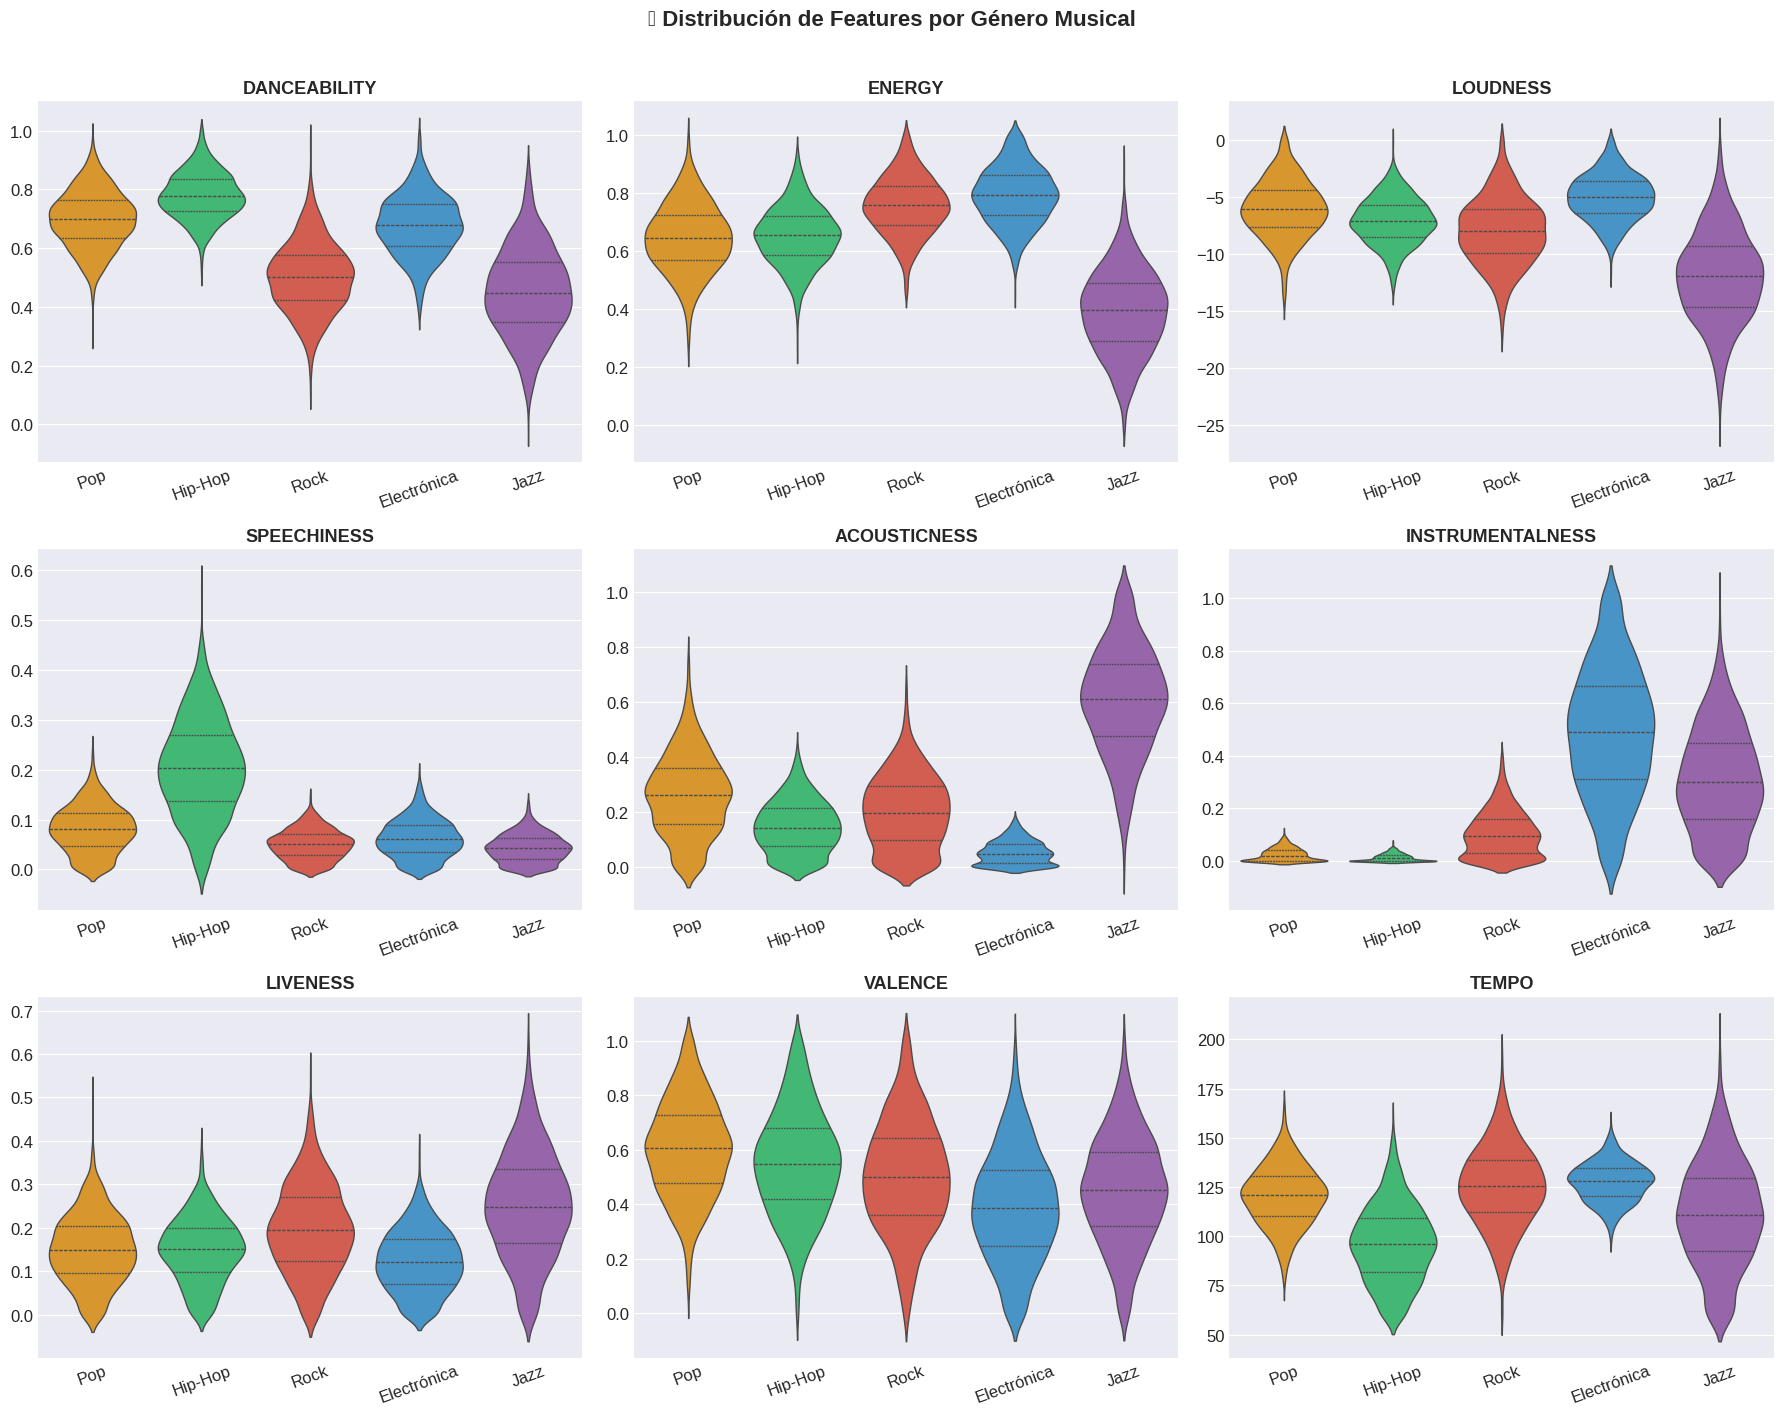

💡 Observa: Jazz tiene baja energy y alta acousticness.
   Hip-Hop tiene alta speechiness. Electrónica tiene alta instrumentalness.
   Estos patrones son los que nuestra red neuronal aprenderá a detectar.


In [5]:
# ============================================================
# 🎻 Distribución de features por género (Violin Plots)
# ============================================================
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
colors = {'Rock': '#E74C3C', 'Pop': '#F39C12', 'Hip-Hop': '#2ECC71',
          'Electrónica': '#3498DB', 'Jazz': '#9B59B6'}

for i, (feat, ax) in enumerate(zip(features, axes.flat)):
    sns.violinplot(data=df, x='genre', y=feat, ax=ax, palette=colors,
                   inner='quartile', linewidth=1)
    ax.set_title(feat.upper(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('🎵 Distribución de Features por Género Musical',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Observa: Jazz tiene baja energy y alta acousticness.")
print("   Hip-Hop tiene alta speechiness. Electrónica tiene alta instrumentalness.")
print("   Estos patrones son los que nuestra red neuronal aprenderá a detectar.")


/tmp/ipykernel_3531/4182545250.py:25: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/4182545250.py:25: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


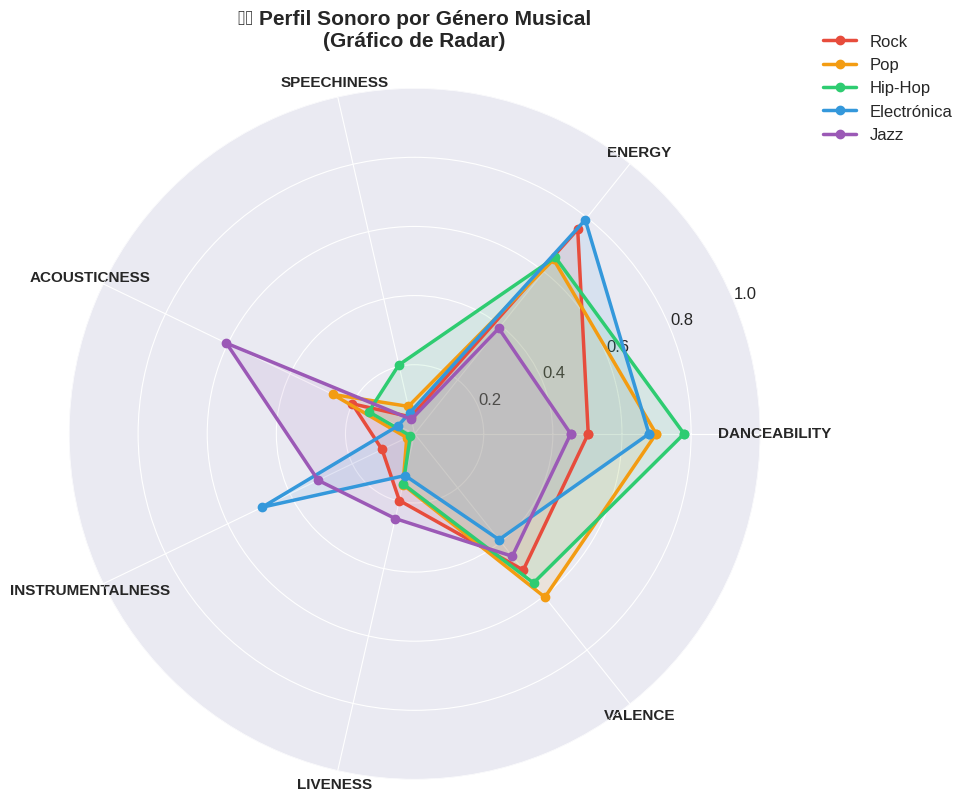

🎯 Este gráfico muestra el 'ADN sonoro' de cada género.
   La red neuronal aprenderá a reconocer estos patrones.


In [6]:
# ============================================================
# 🕸️ Gráfico de Radar — Perfil sonoro de cada género
# ============================================================
feature_names = ['danceability', 'energy', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness', 'valence']

means = df.groupby('genre')[feature_names].mean()
angles = np.linspace(0, 2 * np.pi, len(feature_names), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for genre in genres:
    values = means.loc[genre].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=genre, color=colors[genre], markersize=6)
    ax.fill(angles, values, alpha=0.1, color=colors[genre])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.upper() for f in feature_names], fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('🕸️ Perfil Sonoro por Género Musical\n(Gráfico de Radar)',
             fontsize=15, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.show()

print("🎯 Este gráfico muestra el 'ADN sonoro' de cada género.")
print("   La red neuronal aprenderá a reconocer estos patrones.")


/tmp/ipykernel_3531/1853023204.py:10: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


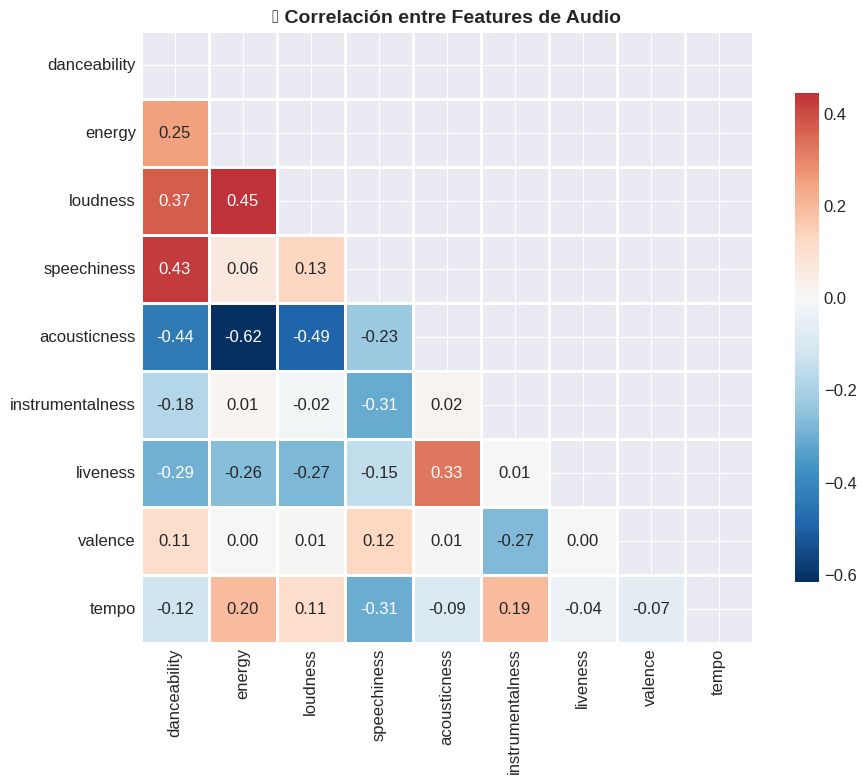

In [7]:
# ============================================================
# 🔥 Mapa de correlaciones
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Correlación entre Features de Audio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ⚙️ Parte 3: Preprocesamiento — De DataFrame a Tensores PyTorch

> 🔗 **Conexión con la teoría:** En el apartado 3.1 vimos que los datos en Deep Learning se representan como **tensores**. Ahora vamos a convertir nuestro DataFrame de pandas en tensores de PyTorch.

Pasos:
1. **Codificar etiquetas** → Convertir nombres de género a números (0, 1, 2, 3, 4)
2. **Normalizar features** → StandardScaler para que todas tengan media 0 y std 1
3. **Dividir datos** → Train (70%), Validación (15%), Test (15%)
4. **Convertir a tensores** → `torch.FloatTensor` para features, `torch.LongTensor` para etiquetas
5. **Crear DataLoaders** → Para procesamiento por lotes (batch processing)


In [9]:
# ============================================================
# ⚙️ Preprocesamiento completo
# ============================================================
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[feature_cols].values
y_labels = df['genre'].values

# Codificar etiquetas
le = LabelEncoder()
y = le.fit_transform(y_labels)
print(f"🏷️ Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Dividir: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Normalizar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Tensores
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# DataLoaders
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n📐 Shapes:")
print(f"   Train: {X_train_t.shape} → {y_train_t.shape}")
print(f"   Val:   {X_val_t.shape} → {y_val_t.shape}")
print(f"   Test:  {X_test_t.shape} → {y_test_t.shape}")
print(f"\n📦 Batches: {len(train_loader)} train, {len(val_loader)} val, {len(test_loader)} test")


🏷️ Clases: {'Electrónica': np.int64(0), 'Hip-Hop': np.int64(1), 'Jazz': np.int64(2), 'Pop': np.int64(3), 'Rock': np.int64(4)}

📐 Shapes:
   Train: torch.Size([3500, 9]) → torch.Size([3500])
   Val:   torch.Size([750, 9]) → torch.Size([750])
   Test:  torch.Size([750, 9]) → torch.Size([750])

📦 Batches: 55 train, 12 val, 12 test


---
## 🧠 Parte 4: Construyendo la Red Neuronal

> 🔗 **Conexión con la teoría:** Implementamos un **Perceptrón Multicapa (MLP)** — la arquitectura feedforward del apartado 4.1. Cada capa realiza **y = f(Wx + b)**.

```
  Entrada (9 features)
       │
  ┌────▼─────┐
  │Linear(128)│ + BatchNorm + ReLU + Dropout(0.3)
  └────┬─────┘
  ┌────▼────┐
  │Linear(64)│ + BatchNorm + ReLU + Dropout(0.3)
  └────┬────┘
  ┌────▼────┐
  │Linear(32)│ + ReLU
  └────┬────┘
  ┌────▼───┐
  │Linear(5)│ → 5 géneros
  └────────┘
```


In [15]:
# ============================================================
# 🧠 Definición del modelo MLP
# ============================================================
class GenreClassifier(nn.Module):
    def __init__(self, input_size=9, num_classes=5):
        super(GenreClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128), # bloque 1
            nn.BatchNorm1d(128),# bloque 1
            nn.ReLU(),# bloque 1
            nn.Dropout(0.3),# bloque 2
            nn.Linear(128, 64),# bloque 2
            nn.BatchNorm1d(64),# bloque 2
            nn.ReLU(),# bloque 2
            nn.Dropout(0.3),# bloque 2
            nn.Linear(64, 32),# bloque 3
            nn.ReLU(),# bloque 3
            nn.Linear(32, num_classes) # bloque 3
        )

    def forward(self, x):
        return self.network(x)

model = GenreClassifier().to(device)
total_params = sum(p.numel() for p in model.parameters())
print("🧠 Arquitectura del modelo:")
print(model)
print(f"\n📊 Parámetros totales: {total_params:,}")


🧠 Arquitectura del modelo:
GenreClassifier(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=5, bias=True)
  )
)

📊 Parámetros totales: 12,165


### 📝 Ejercicio 1: Cuenta los parámetros a mano

- **Capa 1:** Linear(9, 128) → 9×128 + 128 = ?
- **BatchNorm1d(128):** 128 + 128 = ?
- **Capa 2:** Linear(128, 64) → ?
- **BatchNorm1d(64):** ?
- **Capa 3:** Linear(64, 32) → ?
- **Capa 4:** Linear(32, 5) → ?
- **Total:** ?

> 💡 Comprueba con: `sum(p.numel() for p in model.parameters())`


---
## 🔥 Parte 5: Entrenamiento

> 🔗 **Conexión con la teoría (apartado 4.3 — Backpropagation):**
> 1. **Forward pass:** datos → red → predicción
> 2. **Cálculo de pérdida:** CrossEntropyLoss (entropía cruzada, §3.2)
> 3. **Backward pass:** gradientes con regla de la cadena
> 4. **Actualización:** Adam ajusta los pesos (§4.2)


In [16]:
# ============================================================
# 🔥 Función de entrenamiento reutilizable
# ============================================================
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001,
                optimizer_name='Adam', weight_decay=0, verbose=True):
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'SGD_momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['train_acc'].append(train_correct / train_total)
        history['val_acc'].append(val_correct / val_total)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f} | "
                  f"Train Acc: {history['train_acc'][-1]:.3f} | "
                  f"Val Acc: {history['val_acc'][-1]:.3f}")
    return history


In [17]:
# ============================================================
# 🚀 ¡Entrenemos!
# ============================================================
print("🚀 Iniciando entrenamiento...\n")
model = GenreClassifier().to(device)
history = train_model(model, train_loader, val_loader, epochs=100, lr=0.001, optimizer_name='Adam')
print(f"\n✅ Entrenamiento completado!")
print(f"   Mejor val accuracy: {max(history['val_acc']):.3f} (época {np.argmax(history['val_acc'])+1})")


🚀 Iniciando entrenamiento...

Época  10/100 | Train Loss: 0.3162 | Val Loss: 0.2475 | Train Acc: 0.881 | Val Acc: 0.900
Época  20/100 | Train Loss: 0.2896 | Val Loss: 0.2400 | Train Acc: 0.889 | Val Acc: 0.904
Época  30/100 | Train Loss: 0.2755 | Val Loss: 0.2342 | Train Acc: 0.892 | Val Acc: 0.899
Época  40/100 | Train Loss: 0.2629 | Val Loss: 0.2236 | Train Acc: 0.900 | Val Acc: 0.913
Época  50/100 | Train Loss: 0.2504 | Val Loss: 0.2268 | Train Acc: 0.906 | Val Acc: 0.909
Época  60/100 | Train Loss: 0.2440 | Val Loss: 0.2256 | Train Acc: 0.908 | Val Acc: 0.900
Época  70/100 | Train Loss: 0.2392 | Val Loss: 0.2236 | Train Acc: 0.904 | Val Acc: 0.901
Época  80/100 | Train Loss: 0.2420 | Val Loss: 0.2209 | Train Acc: 0.905 | Val Acc: 0.908
Época  90/100 | Train Loss: 0.2303 | Val Loss: 0.2263 | Train Acc: 0.907 | Val Acc: 0.905
Época 100/100 | Train Loss: 0.2337 | Val Loss: 0.2269 | Train Acc: 0.910 | Val Acc: 0.907

✅ Entrenamiento completado!
   Mejor val accuracy: 0.913 (época 40)


/tmp/ipykernel_3531/3072000379.py:19: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/3072000379.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/3072000379.py:19: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing fro

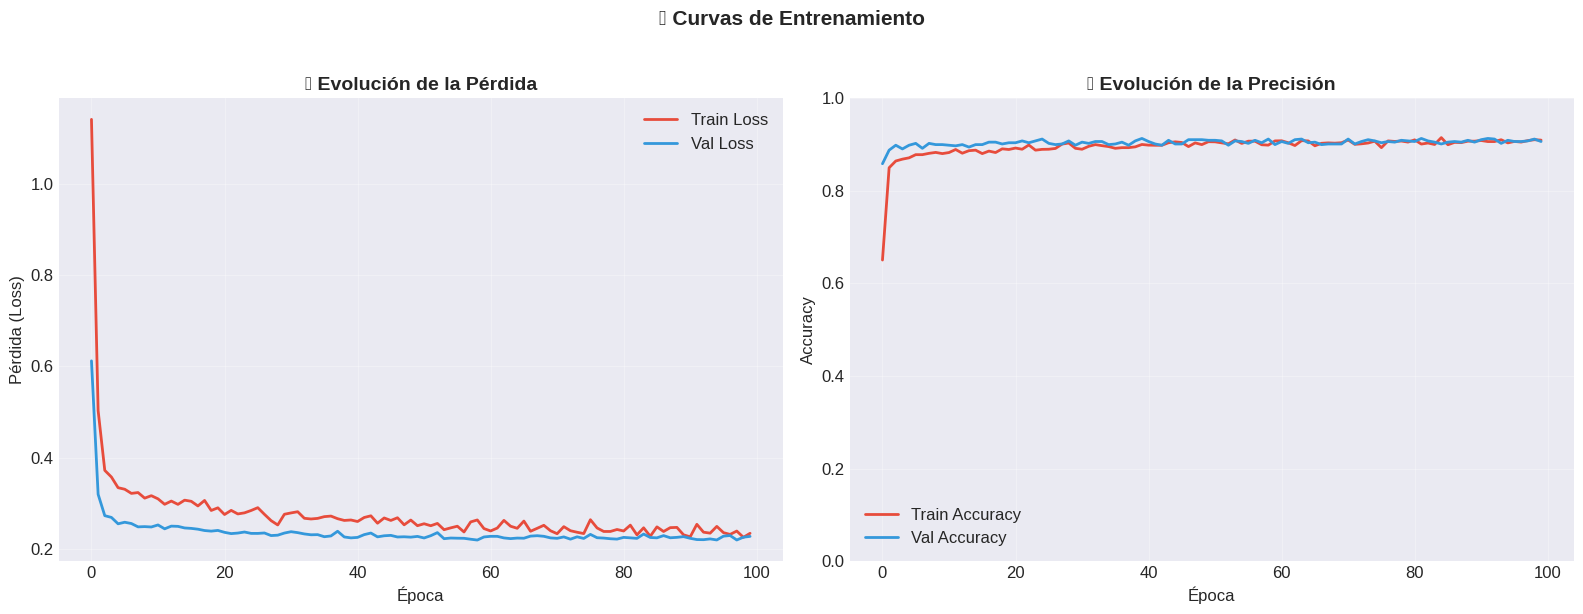

In [18]:
# ============================================================
# 📈 Curvas de entrenamiento
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history['train_loss'], label='Train Loss', linewidth=2, color='#E74C3C')
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2, color='#3498DB')
ax1.set_xlabel('Época'); ax1.set_ylabel('Pérdida (Loss)')
ax1.set_title('📉 Evolución de la Pérdida', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='#E74C3C')
ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2, color='#3498DB')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
ax2.set_title('📈 Evolución de la Precisión', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1)

plt.suptitle('🎵 Curvas de Entrenamiento', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 🎯 Parte 6: Evaluación

In [19]:
# ============================================================
# 🎯 Evaluación en test
# ============================================================
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, y_pred = torch.max(outputs, 1)

y_pred_np = y_pred.cpu().numpy()
y_test_np = y_test_t.cpu().numpy()
test_acc = accuracy_score(y_test_np, y_pred_np)
print(f"🎯 Accuracy en Test: {test_acc:.4f} ({test_acc*100:.1f}%)\n")
print("📋 Reporte de Clasificación:")
print(classification_report(y_test_np, y_pred_np, target_names=le.classes_))


🎯 Accuracy en Test: 0.9253 (92.5%)

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

 Electrónica       0.96      0.97      0.97       150
     Hip-Hop       0.89      0.92      0.90       150
        Jazz       0.99      0.98      0.99       150
         Pop       0.85      0.85      0.85       150
        Rock       0.93      0.91      0.92       150

    accuracy                           0.93       750
   macro avg       0.93      0.93      0.93       750
weighted avg       0.93      0.93      0.93       750



/tmp/ipykernel_3531/2035678933.py:13: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/2035678933.py:13: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


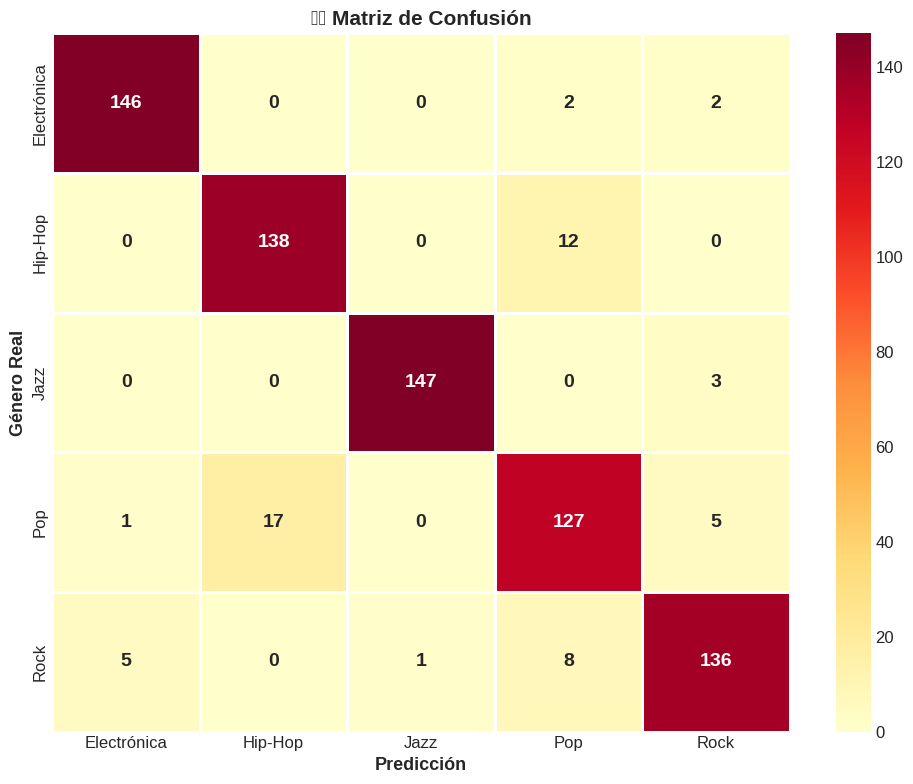

💡 ¿Qué géneros confunde más la red? ¿Tiene sentido musicalmente?


In [20]:
# ============================================================
# 🗺️ Matriz de Confusión
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_np, y_pred_np)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=2, linecolor='white', ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicción', fontsize=13, fontweight='bold')
ax.set_ylabel('Género Real', fontsize=13, fontweight='bold')
ax.set_title('🗺️ Matriz de Confusión', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 ¿Qué géneros confunde más la red? ¿Tiene sentido musicalmente?")


---
## ⚔️ Parte 7: Batalla de Optimizadores

> 🔗 **Conexión con la teoría (§4.2):** Comparamos los optimizadores que estudiamos:
>
> | Optimizador | Tipo | Característica principal |
> |---|---|---|
> | **SGD** | No adaptativo | Simple pero lento |
> | **SGD + Momentum** | No adaptativo | Acumula velocidad |
> | **Adam** | Adaptativo | Momentum + tasa adaptativa |
> | **RMSprop** | Adaptativo | Ajusta tasa por parámetro |


In [23]:
# ============================================================
# ⚔️ Comparación de optimizadores
# ============================================================
print("⚔️ Iniciando batalla de optimizadores...\n")

optimizers_to_test = {
    'SGD (lr=0.01)': ('SGD', 0.01),
    'SGD + Momentum': ('SGD_momentum', 0.01),
    'Adam': ('Adam', 0.001),
    'RMSprop': ('RMSprop', 0.001)
}

optimizer_histories = {}
for name, (opt_name, lr) in optimizers_to_test.items():
    print(f"--- Entrenando con {name} ---")
    torch.manual_seed(42)
    m = GenreClassifier().to(device)
    h = train_model(m, train_loader, val_loader, epochs=80, lr=lr,
                    optimizer_name=opt_name, verbose=False)
    optimizer_histories[name] = h
    print(f"    Val Acc final: {h['val_acc'][-1]:.3f} | Val Loss final: {h['val_loss'][-1]:.4f}")

print("\n✅ Batalla completada!")


⚔️ Iniciando batalla de optimizadores...

--- Entrenando con SGD (lr=0.01) ---
    Val Acc final: 0.900 | Val Loss final: 0.2485
--- Entrenando con SGD + Momentum ---
    Val Acc final: 0.911 | Val Loss final: 0.2232
--- Entrenando con Adam ---
    Val Acc final: 0.911 | Val Loss final: 0.2210
--- Entrenando con RMSprop ---
    Val Acc final: 0.908 | Val Loss final: 0.2257

✅ Batalla completada!


/tmp/ipykernel_3531/10329042.py:20: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/10329042.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/10329042.py:20: UserWarning: Glyph 9876 (\N{CROSSED SWORDS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/10329042.py:20: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(by

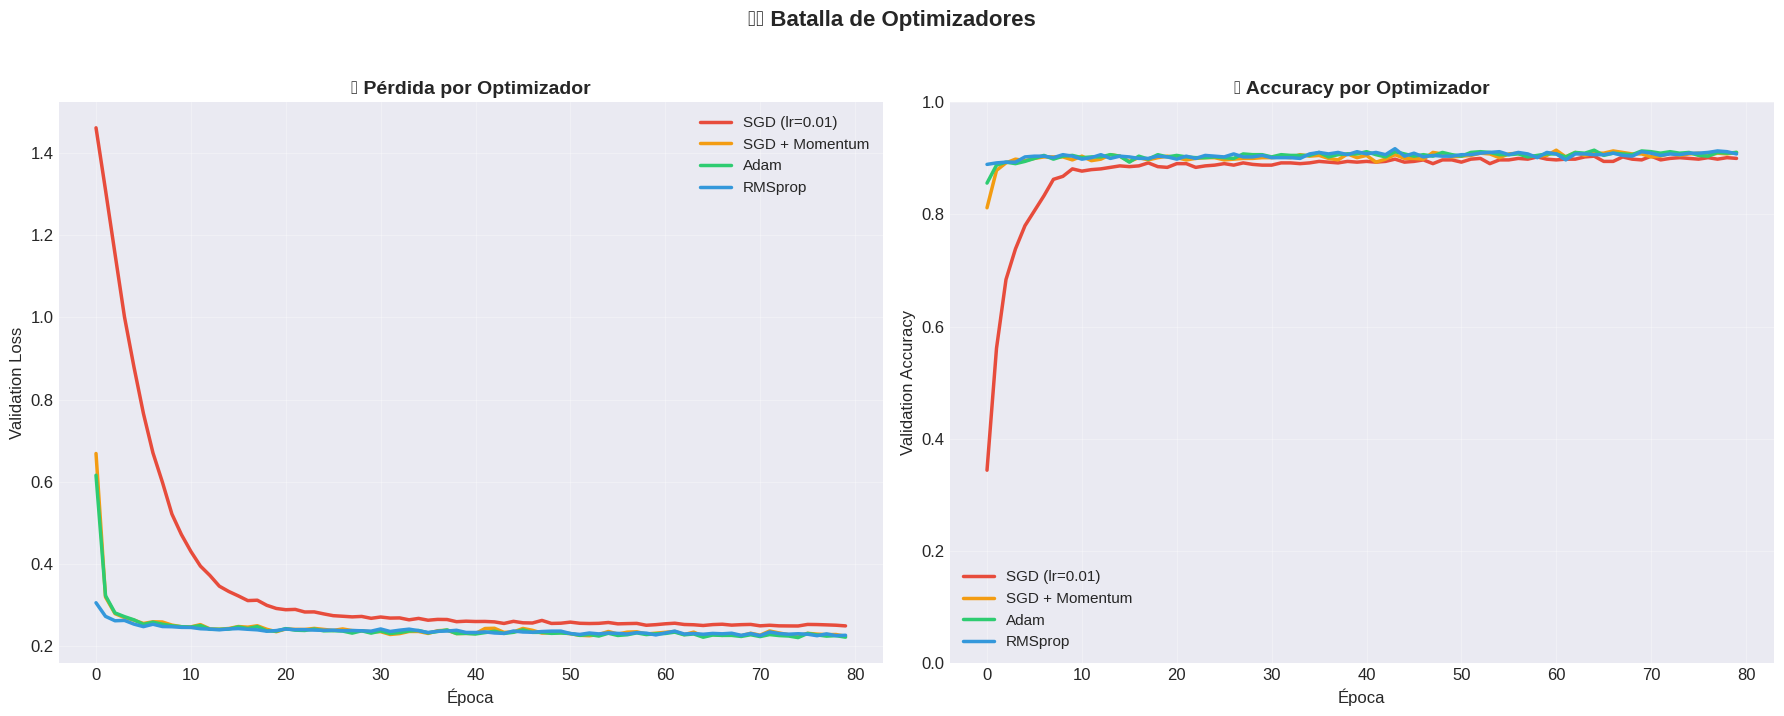

📝 Ejercicio 2: Analiza los resultados:
   - ¿Qué optimizador convergió más rápido?
   - ¿Cuál alcanzó la menor pérdida?
   - ¿Coincide con la teoría del apartado 4.2?


In [24]:
# ============================================================
# 📊 Visualización de la batalla
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors_opt = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']

for (name, h), color in zip(optimizer_histories.items(), colors_opt):
    ax1.plot(h['val_loss'], label=name, linewidth=2.5, color=color)
    ax2.plot(h['val_acc'], label=name, linewidth=2.5, color=color)

ax1.set_xlabel('Época'); ax1.set_ylabel('Validation Loss')
ax1.set_title('📉 Pérdida por Optimizador', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Época'); ax2.set_ylabel('Validation Accuracy')
ax2.set_title('📈 Accuracy por Optimizador', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1)

plt.suptitle('⚔️ Batalla de Optimizadores', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📝 Ejercicio 2: Analiza los resultados:")
print("   - ¿Qué optimizador convergió más rápido?")
print("   - ¿Cuál alcanzó la menor pérdida?")
print("   - ¿Coincide con la teoría del apartado 4.2?")


---
## 🔬 Parte 8: Laboratorio de Hiperparámetros

### Experimento A: Learning Rate
> 🔗 El learning rate (η) controla el paso en el descenso del gradiente: **w = w - η·∇L**


🔬 Impacto del Learning Rate

  lr=0.1      → Val Acc: 0.900 | Val Loss: 0.3043
  lr=0.01     → Val Acc: 0.909 | Val Loss: 0.2278
  lr=0.001    → Val Acc: 0.911 | Val Loss: 0.2210
  lr=0.0001   → Val Acc: 0.900 | Val Loss: 0.2489


/tmp/ipykernel_3531/2095383363.py:28: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/2095383363.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/2095383363.py:28: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


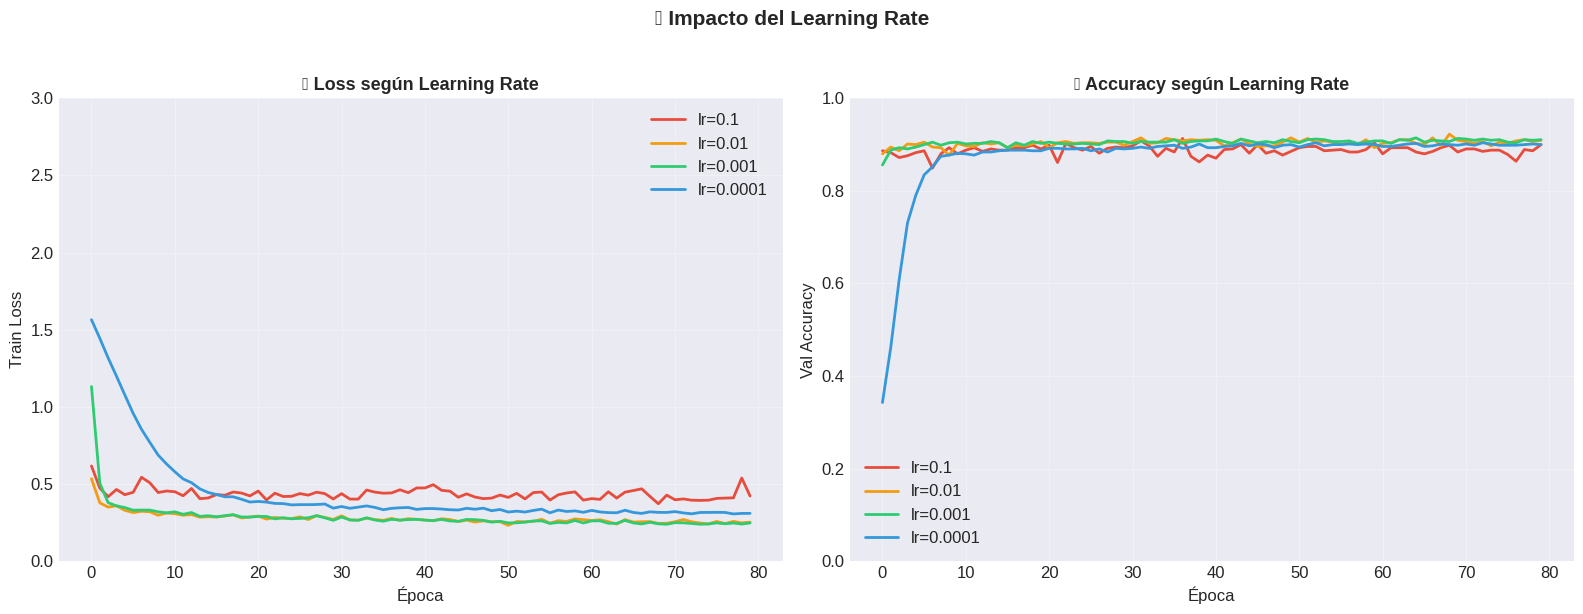

In [25]:
# ============================================================
# 🔬 Experimento: Learning Rate
# ============================================================
print("🔬 Impacto del Learning Rate\n")
learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_histories = {}
for lr in learning_rates:
    torch.manual_seed(42)
    m = GenreClassifier().to(device)
    h = train_model(m, train_loader, val_loader, epochs=80, lr=lr, optimizer_name='Adam', verbose=False)
    lr_histories[f'lr={lr}'] = h
    print(f"  lr={lr:<8} → Val Acc: {h['val_acc'][-1]:.3f} | Val Loss: {h['val_loss'][-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors_lr = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
for (name, h), c in zip(lr_histories.items(), colors_lr):
    ax1.plot(h['train_loss'], label=name, linewidth=2, color=c)
    ax2.plot(h['val_acc'], label=name, linewidth=2, color=c)

ax1.set_xlabel('Época'); ax1.set_ylabel('Train Loss')
ax1.set_title('📉 Loss según Learning Rate', fontsize=13, fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 3)
ax2.set_xlabel('Época'); ax2.set_ylabel('Val Accuracy')
ax2.set_title('📈 Accuracy según Learning Rate', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 1)

plt.suptitle('🔬 Impacto del Learning Rate', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Experimento B: Dropout
> 🔗 El Dropout (§3.3) desactiva neuronas aleatoriamente, creando un ensamblado implícito que mejora la generalización.


🔬 Impacto del Dropout

  Dropout=0.0 → Train: 0.965 | Val: 0.892 | Gap: 0.073
  Dropout=0.2 → Train: 0.917 | Val: 0.909 | Gap: 0.008
  Dropout=0.4 → Train: 0.903 | Val: 0.908 | Gap: -0.005
  Dropout=0.6 → Train: 0.887 | Val: 0.907 | Gap: -0.019


/tmp/ipykernel_3531/3589710302.py:43: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/3589710302.py:43: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


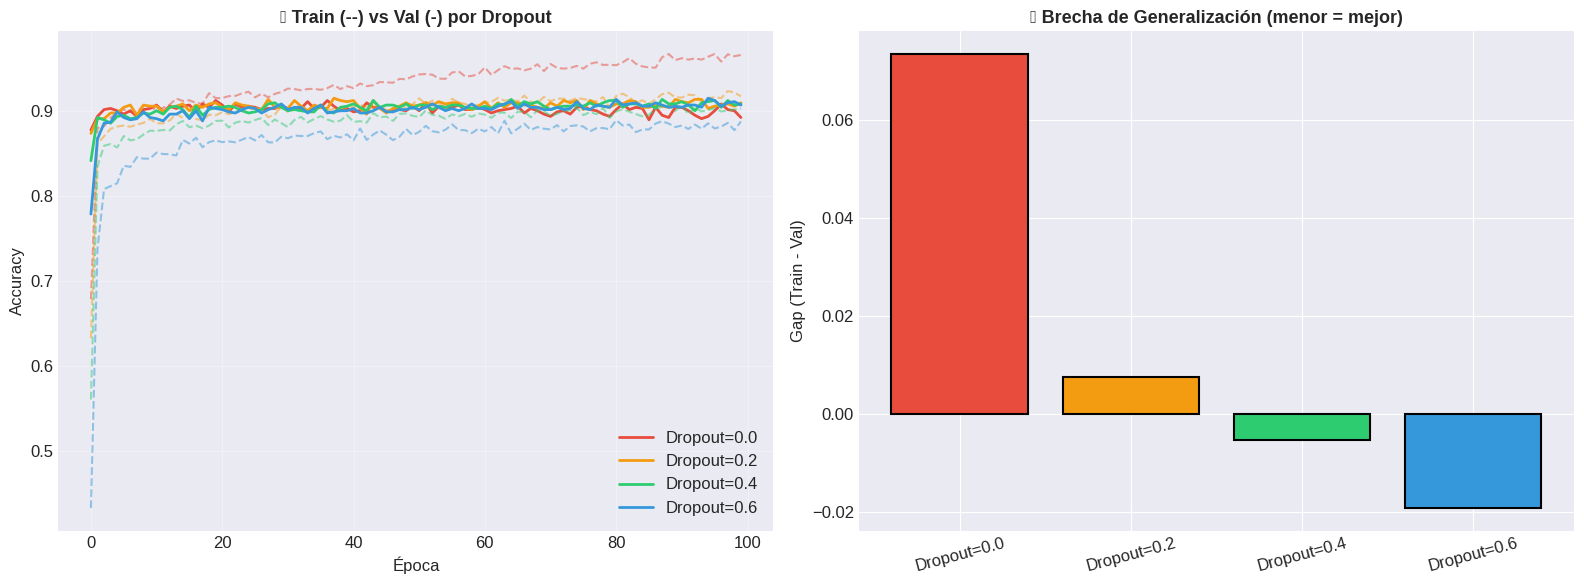

In [26]:
# ============================================================
# 🔬 Experimento: Dropout
# ============================================================
print("🔬 Impacto del Dropout\n")

class FlexibleClassifier(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(9, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 5)
        )
    def forward(self, x):
        return self.network(x)

dropout_rates = [0.0, 0.2, 0.4, 0.6]
dropout_histories = {}
for dr in dropout_rates:
    torch.manual_seed(42)
    m = FlexibleClassifier(dropout_rate=dr).to(device)
    h = train_model(m, train_loader, val_loader, epochs=100, lr=0.001, optimizer_name='Adam', verbose=False)
    dropout_histories[f'Dropout={dr}'] = h
    gap = h['train_acc'][-1] - h['val_acc'][-1]
    print(f"  Dropout={dr} → Train: {h['train_acc'][-1]:.3f} | Val: {h['val_acc'][-1]:.3f} | Gap: {gap:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_dr = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
for (name, h), c in zip(dropout_histories.items(), colors_dr):
    axes[0].plot(h['train_acc'], '--', color=c, alpha=0.5)
    axes[0].plot(h['val_acc'], '-', color=c, label=name, linewidth=2)

axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('📈 Train (--) vs Val (-) por Dropout', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

gaps = {name: h['train_acc'][-1] - h['val_acc'][-1] for name, h in dropout_histories.items()}
axes[1].bar(gaps.keys(), gaps.values(), color=colors_dr, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Gap (Train - Val)')
axes[1].set_title('📊 Brecha de Generalización (menor = mejor)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


---
## 🎤 Parte 9: ¡Clasifica tu Canción Favorita!

Vamos a probar el modelo con canciones reales usando features aproximados de Spotify.


/tmp/ipykernel_3531/3583891897.py:57: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/3583891897.py:57: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/3583891897.py:57: UserWarning: Glyph 127929 (\N{MUSICAL KEYBOARD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3531/3583891897.py:57: UserWarning: Glyph 127927 (\N{SAXOPHONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/

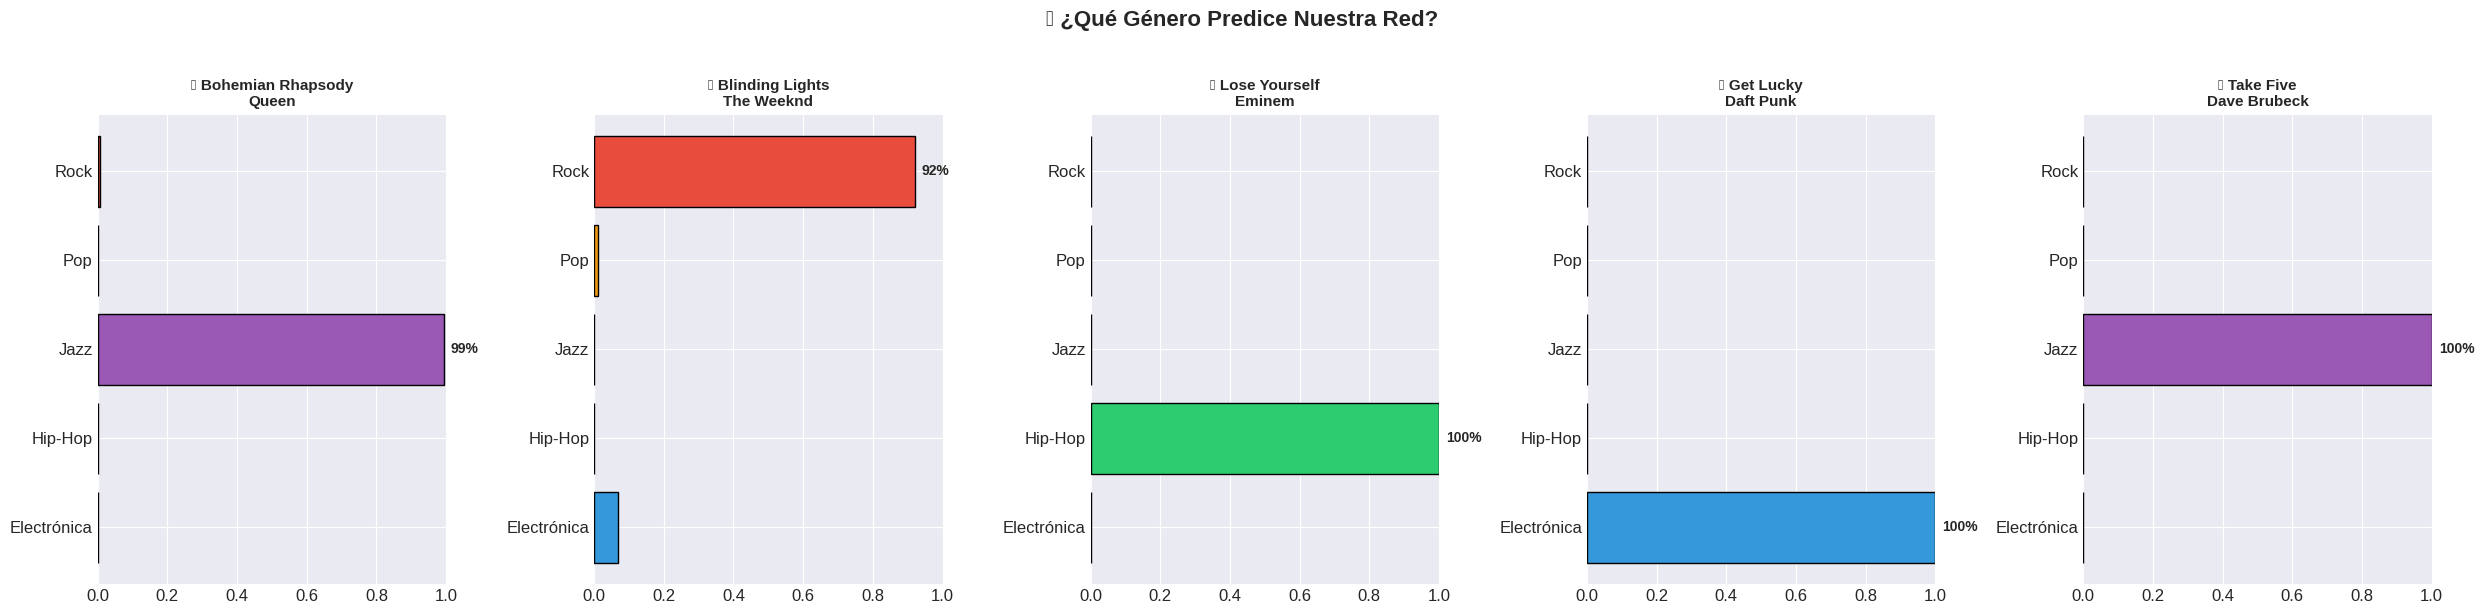

In [28]:
# ============================================================
# 🎤 Demo interactiva
# ============================================================
def predict_genre(features_dict, model, scaler, label_encoder):
    feature_order = ['danceability', 'energy', 'loudness', 'speechiness',
                     'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    values = np.array([[features_dict[f] for f in feature_order]])
    values_scaled = scaler.transform(values)
    tensor = torch.FloatTensor(values_scaled).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
    return dict(zip(label_encoder.classes_, probs))

canciones = {
    '🎸 Bohemian Rhapsody\nQueen': {
        'danceability': 0.39, 'energy': 0.40, 'loudness': -10.0,
        'speechiness': 0.05, 'acousticness': 0.30, 'instrumentalness': 0.0,
        'liveness': 0.25, 'valence': 0.22, 'tempo': 72},
    '🎤 Blinding Lights\nThe Weeknd': {
        'danceability': 0.51, 'energy': 0.73, 'loudness': -5.9,
        'speechiness': 0.06, 'acousticness': 0.00, 'instrumentalness': 0.0,
        'liveness': 0.09, 'valence': 0.33, 'tempo': 171},
    '🎤 Lose Yourself\nEminem': {
        'danceability': 0.75, 'energy': 0.83, 'loudness': -5.6,
        'speechiness': 0.30, 'acousticness': 0.07, 'instrumentalness': 0.0,
        'liveness': 0.30, 'valence': 0.37, 'tempo': 87},
    '🎹 Get Lucky\nDaft Punk': {
        'danceability': 0.79, 'energy': 0.78, 'loudness': -5.0,
        'speechiness': 0.03, 'acousticness': 0.01, 'instrumentalness': 0.40,
        'liveness': 0.10, 'valence': 0.70, 'tempo': 116},
    '🎷 Take Five\nDave Brubeck': {
        'danceability': 0.35, 'energy': 0.25, 'loudness': -15.0,
        'speechiness': 0.03, 'acousticness': 0.85, 'instrumentalness': 0.90,
        'liveness': 0.20, 'valence': 0.30, 'tempo': 174}
}

genre_colors = {'Rock': '#E74C3C', 'Pop': '#F39C12', 'Hip-Hop': '#2ECC71',
                'Electrónica': '#3498DB', 'Jazz': '#9B59B6'}

fig, axes = plt.subplots(1, len(canciones), figsize=(5*len(canciones), 6))
for ax, (song_name, feats) in zip(axes, canciones.items()):
    probs = predict_genre(feats, model, scaler, le)
    colors_bar = [genre_colors[g] for g in probs.keys()]
    bars = ax.barh(list(probs.keys()), list(probs.values()), color=colors_bar,
                   edgecolor='black', linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_title(song_name, fontsize=11, fontweight='bold')
    winner = max(probs, key=probs.get)
    for bar, (genre, prob) in zip(bars, probs.items()):
        if genre == winner:
            ax.text(prob + 0.02, bar.get_y() + bar.get_height()/2,
                    f'{prob:.0%}', va='center', fontweight='bold', fontsize=10)

plt.suptitle('🎤 ¿Qué Género Predice Nuestra Red?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 📝 Ejercicio 3: ¡Tu turno!

Busca los features de tu canción favorita y prueba el modelo:

```python
mi_cancion = {
    'danceability': 0.7, 'energy': 0.8, 'loudness': -5.0,
    'speechiness': 0.05, 'acousticness': 0.1, 'instrumentalness': 0.0,
    'liveness': 0.15, 'valence': 0.6, 'tempo': 120
}
probs = predict_genre(mi_cancion, model, scaler, le)
for genre, prob in sorted(probs.items(), key=lambda x: -x[1]):
    print(f"  {genre}: {prob:.1%}")
```


---
## 🏁 Conclusiones

| Concepto de la Unidad 1 | Lo que hicimos |
|---|---|
| **Tensores** (§3.1) | Canciones como vectores de 9 features |
| **MLP / Feedforward** (§4.1) | Clasificador con 3 capas ocultas |
| **ReLU** (§4.1) | Activación en capas ocultas |
| **Backpropagation** (§4.3) | `loss.backward()` |
| **Cross Entropy** (§3.2) | Función de pérdida multiclase |
| **Optimizadores** (§4.2) | SGD vs Adam vs RMSprop |
| **Regularización** (§3.3) | Dropout y BatchNorm |
| **Learning Rate** (§3.2) | Impacto en la convergencia |
| **PyTorch** (§5.1) | Framework de toda la práctica |

### 🔑 Ideas clave:
- La **elección del optimizador** impacta enormemente en velocidad y calidad
- El **learning rate** es el hiperparámetro más crítico
- El **Dropout** reduce la brecha train/val (mejor generalización)
- Las redes neuronales aprenden patrones complejos de datos numéricos simples

---
*Práctica desarrollada para UTAMED — Deep Learning, Unidad 1*
